# Dual-Stream SpoofFormer — Real-World Inference Test

Tests the model on 4 photos from outside the training dataset:
- **Sample 1**: CelebA photo (real face, external dataset)
- **Sample 2**: Printed/displayed fake of CelebA photo (spoof)
- **Sample 3**: Live selfie taken directly on camera (real)
- **Sample 4**: Photo of that selfie displayed on screen (spoof)

MiDaS generates depth maps at runtime — no pre-computed depth needed.

In [10]:
# ── Setup ─────────────────────────────────────────────────
import sys
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from PIL import Image

sys.path.insert(0, str(Path('.').resolve()))
from models.model import spoofformer_small

CHECKPOINT = 'checkpoints/best_model.pth'
IMG_SIZE   = 128
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device : {DEVICE}')

Device : cuda


In [11]:

SAMPLES = [
    {'path': 'test_samples/1real.jpg', 'label': 0, 'desc': 'Real Sample 1'},
    {'path': 'test_samples/1fake.jpg', 'label': 1, 'desc': 'Spoof Sample 1'},
    {'path': 'test_samples/2real.jpg', 'label': 0, 'desc': 'Real Sample 2'},
    {'path': 'test_samples/2fake.jpg', 'label': 1, 'desc': 'Spoof Sample 2'},
]

missing = [s['path'] for s in SAMPLES if not Path(s['path']).exists()]
if missing:
    print('⚠ Missing files:')
    for m in missing:
        print(f'   {m}')
else:
    print('✓ All 4 test images found')


✓ All 4 test images found


In [12]:
# ── Load SpoofFormer model ────────────────────────────────
model = spoofformer_small(img_size=IMG_SIZE, use_midas=False)
ckpt  = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'])
model.eval().to(DEVICE)
print(f'✓ SpoofFormer loaded — epoch {ckpt.get("epoch","?")}, Val ACER={ckpt.get("best_acer",0)*100:.2f}%')

✓ SpoofFormer loaded — epoch 5, Val ACER=4.64%


In [13]:
# ── Load MiDaS depth estimator ────────────────────────────
print('Loading MiDaS_small...')
midas = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small',
                        trust_repo=True, verbose=False)
midas.eval().to(DEVICE)
for p in midas.parameters():
    p.requires_grad = False
print('✓ MiDaS loaded')

Loading MiDaS_small...
Loading weights:  None


Using cache found in C:\Users\express/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


✓ MiDaS loaded


In [14]:
# ── Helper functions ──────────────────────────────────────

@torch.no_grad()
def generate_depth(rgb_bgr: np.ndarray) -> np.ndarray:
    """Generate MiDaS depth map from BGR image. Returns uint8 grayscale."""
    h, w   = rgb_bgr.shape[:2]
    img_rgb = cv2.cvtColor(rgb_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    tensor  = torch.from_numpy(img_rgb).permute(2,0,1).unsqueeze(0).to(DEVICE)
    resized = F.interpolate(tensor, size=(256,256), mode='bilinear', align_corners=False)
    depth   = midas(resized).squeeze().cpu().numpy()
    depth   = cv2.resize(depth, (w, h))
    depth   = depth - depth.min()
    if depth.max() > 0:
        depth = depth / depth.max()
    return (depth * 255).astype(np.uint8)


def preprocess(img_bgr: np.ndarray, depth_gray: np.ndarray):
    """Preprocess RGB and depth for model input."""
    rgb_pil   = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    depth_pil = Image.fromarray(depth_gray).convert('L')

    rgb_pil   = TF.resize(rgb_pil,   (IMG_SIZE, IMG_SIZE))
    depth_pil = TF.resize(depth_pil, (IMG_SIZE, IMG_SIZE))

    rgb_t   = TF.normalize(TF.to_tensor(rgb_pil),
                           [0.485,0.456,0.406], [0.229,0.224,0.225])
    depth_t = TF.to_tensor(depth_pil)
    return rgb_t.unsqueeze(0), depth_t.unsqueeze(0)


@torch.no_grad()
def predict(rgb_t, depth_t):
    """Run inference. Returns label, confidence, real_prob, spoof_prob."""
    logits = model(rgb_t.to(DEVICE), depth_t.to(DEVICE))
    probs  = torch.softmax(logits, dim=1)[0]
    label  = 'REAL' if probs[0] > probs[1] else 'SPOOF'
    return label, probs.max().item(), probs[0].item(), probs[1].item()

In [15]:
# ── Run inference on all 4 samples ───────────────────────
results = []

for s in SAMPLES:
    img_bgr = cv2.imread(s['path'])
    if img_bgr is None:
        print(f"⚠ Could not read {s['path']} — skipping")
        continue

    depth_gray          = generate_depth(img_bgr)
    rgb_t, depth_t      = preprocess(img_bgr, depth_gray)
    label, conf, rp, sp = predict(rgb_t, depth_t)

    gt      = 'REAL' if s['label'] == 0 else 'SPOOF'
    correct = label == gt

    results.append({
        **s,
        'img_bgr':    img_bgr,
        'depth_gray': depth_gray,
        'pred':       label,
        'conf':       conf,
        'real_prob':  rp,
        'spoof_prob': sp,
        'correct':    correct,
        'gt':         gt,
    })
    status = '✓' if correct else '✗'
    print(f"{status} {s['desc']:<22} GT={gt:<6} PRED={label:<6} conf={conf*100:.1f}%")

✓ Real Sample 1          GT=REAL   PRED=REAL   conf=98.8%
✓ Spoof Sample 1         GT=SPOOF  PRED=SPOOF  conf=85.4%
✓ Real Sample 2          GT=REAL   PRED=REAL   conf=98.2%
✓ Spoof Sample 2         GT=SPOOF  PRED=SPOOF  conf=83.3%


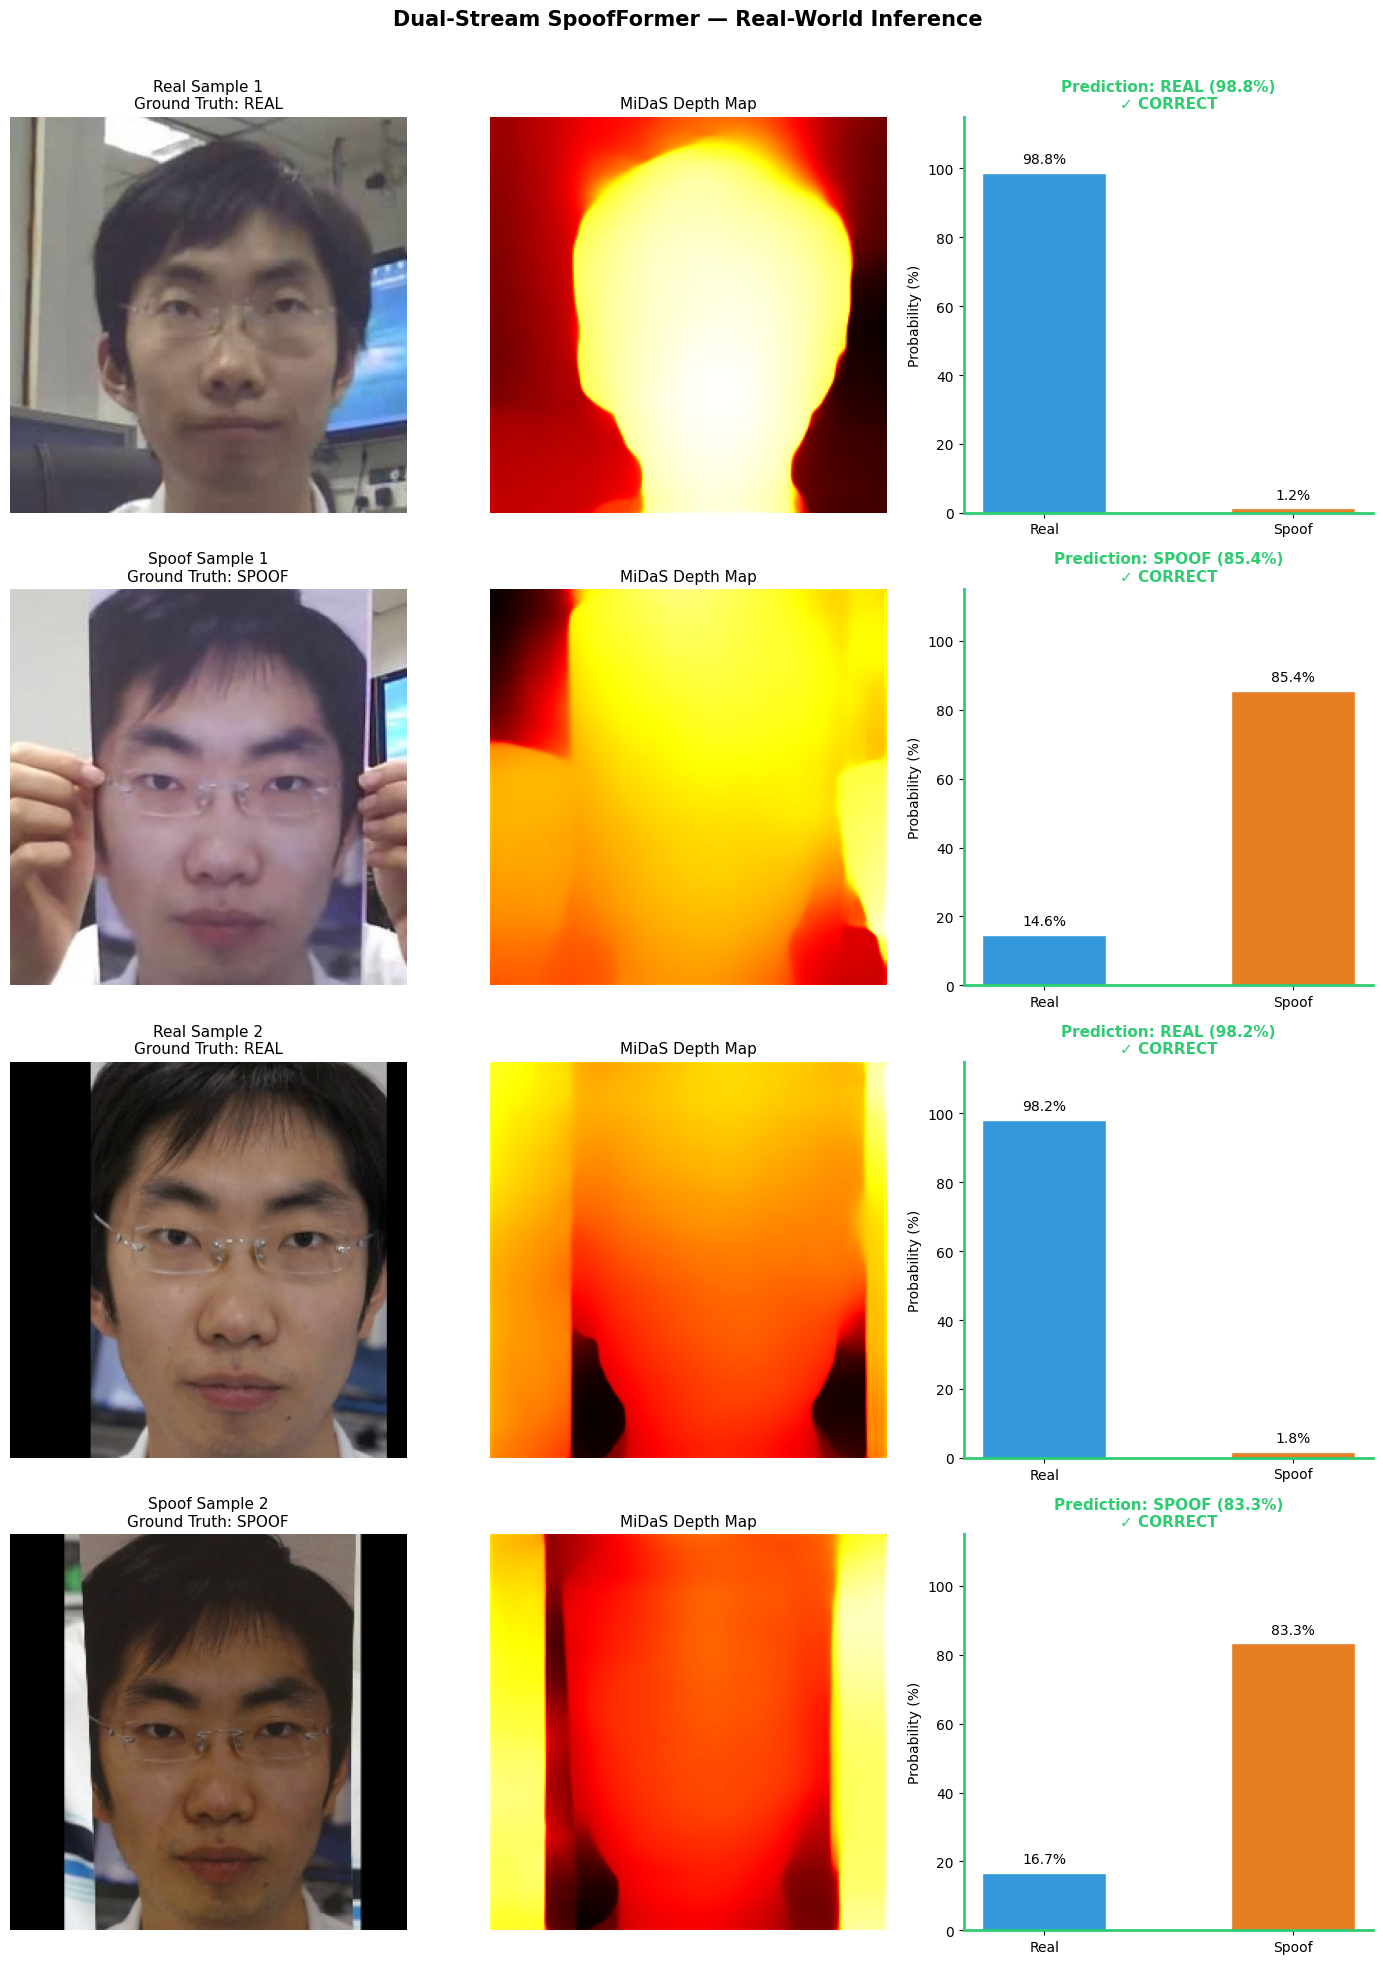

Saved: test_results.png


In [16]:
# ── Visualize ─────────────────────────────────────────────
n = len(results)
fig, axes = plt.subplots(n, 3, figsize=(14, 5*n))
if n == 1:
    axes = [axes]
fig.suptitle('Dual-Stream SpoofFormer — Real-World Inference', fontsize=15, fontweight='bold')

for row, r in enumerate(results):
    color  = '#2ecc71' if r['correct'] else '#e74c3c'
    result = '✓ CORRECT' if r['correct'] else '✗ WRONG'
    rgb_vis = cv2.cvtColor(r['img_bgr'], cv2.COLOR_BGR2RGB)

    # Col 0: RGB
    axes[row][0].imshow(rgb_vis)
    axes[row][0].set_title(f"{r['desc']}\nGround Truth: {r['gt']}", fontsize=11)
    axes[row][0].axis('off')

    # Col 1: MiDaS depth
    axes[row][1].imshow(r['depth_gray'], cmap='hot')
    axes[row][1].set_title('MiDaS Depth Map', fontsize=11)
    axes[row][1].axis('off')

    # Col 2: Confidence bar
    ax = axes[row][2]
    bars = ax.bar(['Real', 'Spoof'],
                  [r['real_prob']*100, r['spoof_prob']*100],
                  color=['#3498db', '#e67e22'], width=0.5, edgecolor='white')
    ax.set_ylim(0, 115)
    ax.set_ylabel('Probability (%)')
    ax.set_title(
        f"Prediction: {r['pred']} ({r['conf']*100:.1f}%)\n{result}",
        fontsize=11, color=color, fontweight='bold'
    )
    for bar, val in zip(bars, [r['real_prob']*100, r['spoof_prob']*100]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.spines[['top','right']].set_visible(False)

    for ax_ in axes[row]:
        for spine in ax_.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: test_results.png')

In [17]:
# ── Summary ───────────────────────────────────────────────
correct_count = sum(r['correct'] for r in results)
print(f'\n{"="*62}')
print(f'{"Sample":<22} {"GT":>6} {"Pred":>6} {"Real%":>8} {"Spoof%":>8} {"":>4}')
print(f'{"─"*62}')
for r in results:
    mark = '✓' if r['correct'] else '✗'
    print(f"{r['desc']:<22} {r['gt']:>6} {r['pred']:>6} "
          f"{r['real_prob']*100:>7.1f}% {r['spoof_prob']*100:>7.1f}% {mark:>4}")
print(f'{"─"*62}')
print(f'Accuracy: {correct_count}/{len(results)} ({correct_count/len(results)*100:.0f}%)')
print(f'{"="*62}')


Sample                     GT   Pred    Real%   Spoof%     
──────────────────────────────────────────────────────────────
Real Sample 1            REAL   REAL    98.8%     1.2%    ✓
Spoof Sample 1          SPOOF  SPOOF    14.6%    85.4%    ✓
Real Sample 2            REAL   REAL    98.2%     1.8%    ✓
Spoof Sample 2          SPOOF  SPOOF    16.7%    83.3%    ✓
──────────────────────────────────────────────────────────────
Accuracy: 4/4 (100%)
